In [3]:
# installing quickdraw, importing other libs
!pip install quickdraw
from quickdraw import QuickDrawDataGroup
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [8]:
# defining food categories for training/testing
with open('food.txt', 'r') as file:
    # Read text, strip trailing newlines, and split by comma
    CATEGORIES = file.read().strip().split(', ')
SAMPLES = 500

In [9]:
CATEGORIES

['apple',
 'banana',
 'bread',
 'broccoli',
 'cake',
 'carrot',
 'cookie',
 'donut',
 'grapes',
 'hamburger',
 'ice cream',
 'pizza',
 'popsicle',
 'strawberry',
 'watermelon']

In [13]:
images = []
labels = []
label_map = {}

label_index = 0
for category in CATEGORIES:
    group = QuickDrawDataGroup(category, max_drawings=SAMPLES)
    label_map.update({category:label_index})
    label_index = label_index+1
    for drawing in group.drawings:
        img = np.array(drawing.image.convert('L').resize((16, 16)))
        images.append(img)
        labels.append(category)

loading apple drawings
load complete
loading banana drawings
load complete
loading bread drawings
load complete
loading broccoli drawings
load complete
loading cake drawings
load complete
loading carrot drawings
load complete
loading cookie drawings
load complete
loading donut drawings
load complete
loading grapes drawings
load complete
loading hamburger drawings
load complete
loading ice cream drawings
load complete
loading pizza drawings
load complete
loading popsicle drawings
load complete
loading strawberry drawings
load complete
loading watermelon drawings
load complete


In [14]:
label_map

{'apple': 0,
 'banana': 1,
 'bread': 2,
 'broccoli': 3,
 'cake': 4,
 'carrot': 5,
 'cookie': 6,
 'donut': 7,
 'grapes': 8,
 'hamburger': 9,
 'ice cream': 10,
 'pizza': 11,
 'popsicle': 12,
 'strawberry': 13,
 'watermelon': 14}

(np.float64(-0.5), np.float64(15.5), np.float64(15.5), np.float64(-0.5))

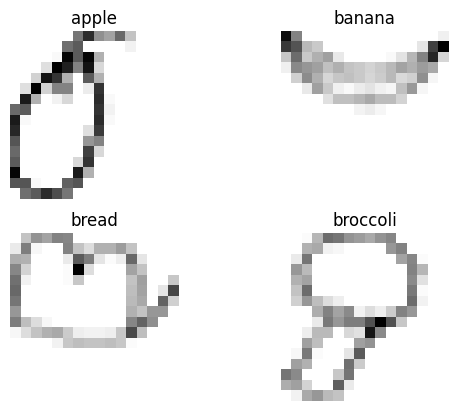

In [11]:
plt.subplot(2, 2, 1)
plt.imshow(images[0], cmap='gray')
plt.title(labels[0])
plt.axis('off')


plt.subplot(2, 2, 2)
plt.imshow(images[500], cmap='gray')
plt.title(labels[500])
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(images[1000], cmap='gray')
plt.title(labels[1000])
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(images[1500], cmap='gray')
plt.title(labels[1500])
plt.axis('off')

In [58]:
# partitioning dataset
X=np.array(images) / 255.0 # standardize to (0,1)
y=np.array(labels)
y = np.array([label_map[l] for l in labels])
X_reshaped = X.reshape(X.shape[0], -1)

X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y, test_size=0.2, stratify=y, random_state=42
)

In [28]:
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (6000, 256), Test: (1500, 256)


In [ ]:
# Referenced this https://www.datacamp.com/tutorial/k-nearest-neighbor-classification-scikit-learn

In [29]:
from sklearn.neighbors import KNeighborsClassifier

In [30]:
# initial training attempt with 3 neighbors
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [31]:
y_pred = knn.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score


In [34]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5813333333333334


In [36]:
from sklearn.model_selection import cross_val_score

In [38]:
# iterating through various neighbor values to determine optimal
k_values = [i for i in range (1,31)]
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_reshaped, y, cv=5)
    scores.append(np.mean(score))

Text(0, 0.5, 'Accuracy Score')

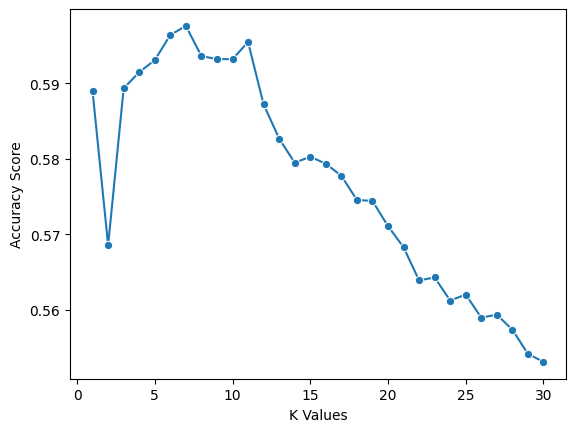

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(x = k_values, y = scores, marker = 'o')
plt.xlabel("K Values")
plt.ylabel("Accuracy Score")

In [41]:
# training again on best # of neighbors (7)
best_index = np.argmax(scores)
best_k = k_values[best_index]

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [65]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [67]:
# view performance metrics
y_pred = knn.predict(X_test)

# not sure which avg metric to pick, apparently micro = accuracy
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred,average='macro')
f1 = f1_score(y_test, y_pred,average='macro')
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Accuracy: 0.6093333333333333
Precision: 0.6378247978163334
Recall: 0.6093333333333334
F1 Score: 0.5951827451431999


In [68]:
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test, y_pred)

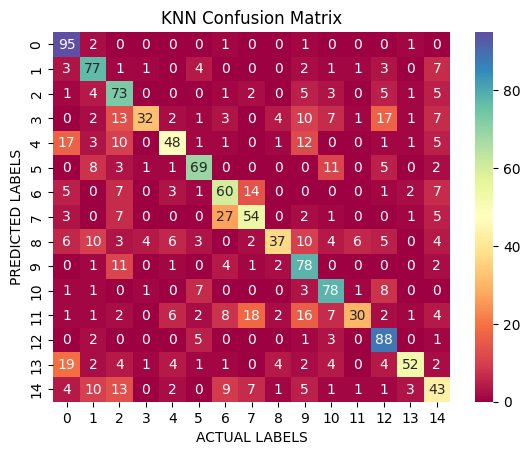

In [69]:
# https://stackoverflow.com/questions/60748497/how-to-include-a-confusion-matrix-for-a-knn-in-python
ax= plt.subplot()
sns.heatmap(cm, annot=True, fmt = "d", cmap="Spectral"); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('ACTUAL LABELS');ax.set_ylabel('PREDICTED LABELS');
ax.set_title('KNN Confusion Matrix');


In [120]:
# additional testing on my own drawing

In [85]:
from skimage import io
from PIL import Image
import numpy as np

In [106]:
X_reshaped[0]

array([1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 0.91764706, 0.8745098 , 0.93333333, 0.94509804,
       0.90980392, 0.96470588, 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 0.91372549, 0.90196078, 1.        , 1.        ,
       1.        , 1.        , 0.99215686, 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 0.99607843, 0.85098039, 0.90196078, 0.85098039,
       0.95294118, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 0.98039216, 0.84705882, 0.86666667, 0.9254902 ,
       0.85882353, 0.97647059, 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 0.97254902, 0.85882353, 0.87843137, 0.95294118,
       1.        , 0.90196078, 0.95294118, 1.        , 1.     

In [116]:
apple_img = Image.open('my_apple.png').convert('L')
apple_arr = np.array(apple_img).reshape(1,-1)/255
apple_arr




array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 0., 1., 1., 1., 0., 0., 1., 1., 1., 0., 1., 1., 1.,
        1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
        1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
        1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
        1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
        1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
        1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 

In [117]:
yeah = knn.predict(apple_arr)

In [118]:
yeah

array([8])

In [119]:
label_map

{'apple': 0,
 'banana': 1,
 'bread': 2,
 'broccoli': 3,
 'cake': 4,
 'carrot': 5,
 'cookie': 6,
 'donut': 7,
 'grapes': 8,
 'hamburger': 9,
 'ice cream': 10,
 'pizza': 11,
 'popsicle': 12,
 'strawberry': 13,
 'watermelon': 14}

In [ ]:
#Nope